# 01 Upward and downward continuation

Ben Kay (ben@auscope.org.au)

A potential field measured on one level can be computed on another. In the
wavenumber domain the field at height h above the observation surface is

    F[T_h] = exp(-h |k|) F[T]        k = 2 pi / wavelength          Blakely 12.7

Short wavelengths (large k) decay fastest, so upward continuation is a
smooth low pass with a physical meaning: it is what an aeromagnetic survey
flown h metres higher would have measured. The difference between the data
and the continued field is a residual dominated by shallow sources.

Downward continuation, exp(+h |k|), amplifies short wavelengths without
bound and has to be paired with a low pass.

All filters share one pipeline (`fft.apply`): fill nulls with the nearest
value, remove a plane fitted to the grid edges, pad by half the grid size
with a cosine taper, FFT, multiply, inverse FFT, trim, add the plane back,
restore nulls.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from potfield import read_grid, write_grid, filters, transforms, spectrum, display

DATA = "../data"
OUT = "../outputs"
INC, DEC = -62.4, 7.5   # IGRF inclination, declination (deg) for the Frome area at 2015.0
plt.rcParams["figure.dpi"] = 90

In [2]:
g = read_grid(f"{DATA}/frome_tmi.ers", bounds=(139.30, -30.60, 139.90, -30.10), epsg=28354, units="nT")
print(g)

Grid('frome_tmi', 658x684, cell 85.3445x85.3445 m (~85x85 m), EPSG:28354, bounds W336193.3012 S6613486.7698 E394568.9500 N6669643.4612, units 'nT')


Text(0.5, 1.0, 'upward continuation response exp(-h k)')

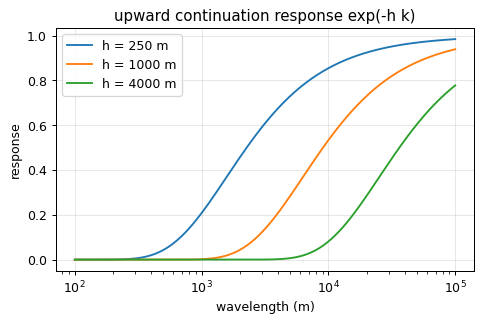

In [3]:
wavelength = np.logspace(2, 5, 200)          # 100 m to 100 km
k = 2 * np.pi / wavelength
fig, ax = plt.subplots(figsize=(6, 3.5))
for h in (250, 1000, 4000):
    ax.semilogx(wavelength, filters.continuation_response(k, h), label=f"h = {h} m")
ax.set_xlabel("wavelength (m)"); ax.set_ylabel("response"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("upward continuation response exp(-h k)")

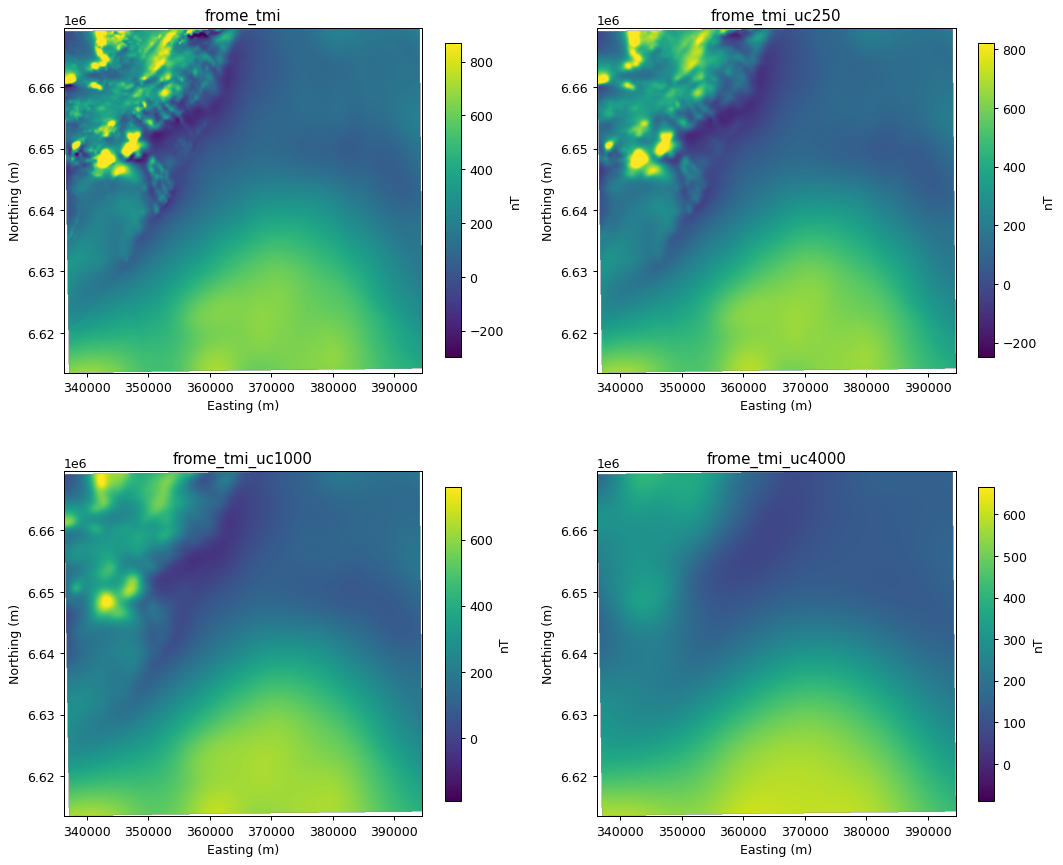

In [4]:
ucs = [filters.upward_continue(g, h) for h in (250, 1000, 4000)]
fig, axes = display.compare([g] + ucs, ncols=2, cmap="viridis", clip=("std", 2.5))

## Regional and residual

`regional_residual` returns the continued field and `data - continued`. The
residual keeps everything the continuation removed, so it is a high pass
whose cutoff is set by a height rather than a wavelength.

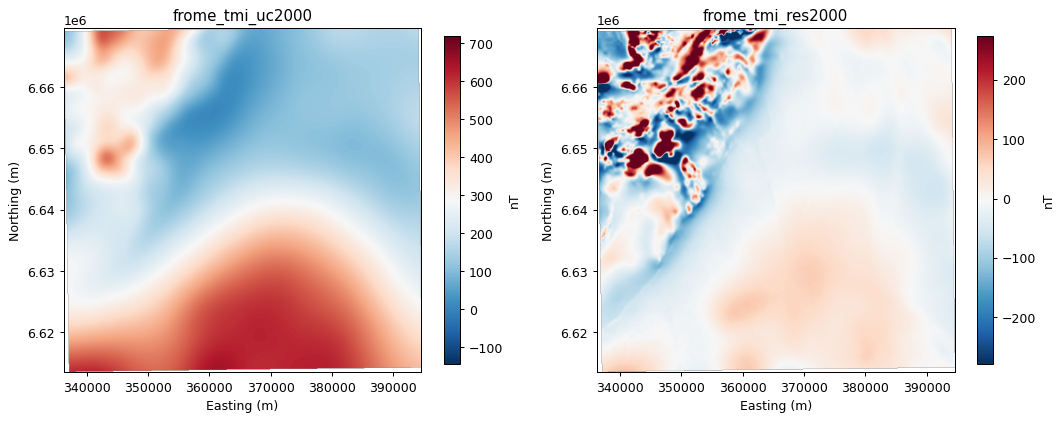

In [5]:
regional, residual = filters.regional_residual(g, 2000)
fig, axes = display.compare([regional, residual], ncols=2, cmap="RdBu_r", clip=("std", 2.5))

## Downward continuation

`downward_continue` multiplies exp(+depth k) by a Butterworth low pass at
`cutoff_wavelength`. With depth larger than a few cells or a cutoff near the
cell size, the result is noise. Compare the responses first.

Text(0.5, 1.0, 'downward continuation with Butterworth low pass')

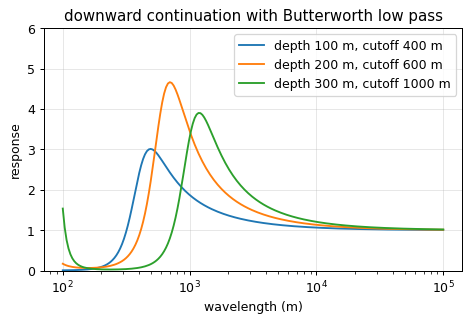

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for depth, cut in ((100, 400), (200, 600), (300, 1000)):
    H = filters.continuation_response(k, -depth) * filters.butterworth_lowpass_response(k, cut, 4)
    ax.semilogx(wavelength, H, label=f"depth {depth} m, cutoff {cut} m")
ax.set_ylim(0, 6); ax.set_xlabel("wavelength (m)"); ax.set_ylabel("response"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("downward continuation with Butterworth low pass")

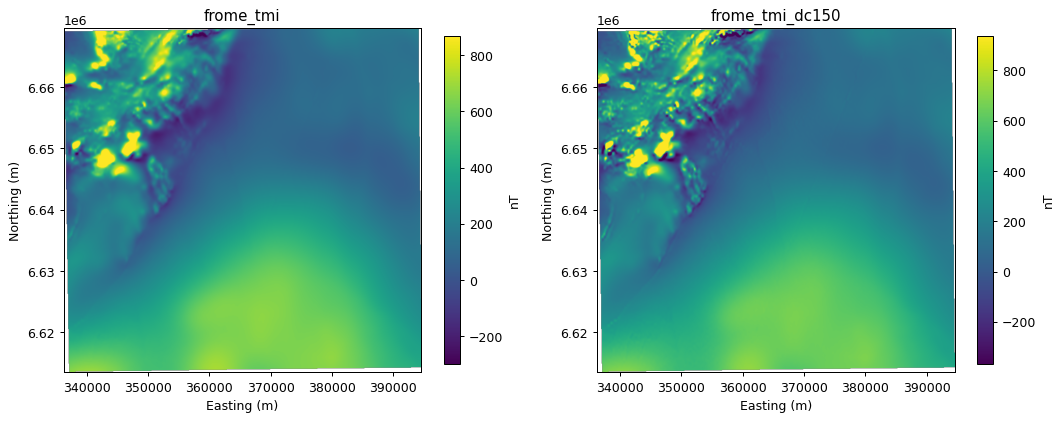

In [7]:
dc = filters.downward_continue(g, depth=150, cutoff_wavelength=500)
fig, axes = display.compare([g, dc], ncols=2, cmap="viridis", clip=("std", 2.5))

In [8]:
import os
os.makedirs(OUT, exist_ok=True)
write_grid(ucs[1], f"{OUT}/frome_tmi_uc1000.grd")
write_grid(residual, f"{OUT}/frome_tmi_res2000.grd")

WindowsPath('../outputs/frome_tmi_res2000.grd')